Raquel

# LIBRARY

In [2]:
# LIBRARY
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Circle, Polygon as MplPolygon
from scipy.spatial import Voronoi, voronoi_plot_2d, cKDTree
from scipy.stats import gaussian_kde
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110

In [3]:
n_pdv = 25
pdv_x = np.random.uniform(0, 10000, n_pdv)
pdv_y = np.random.uniform(0, 10000, n_pdv)

n_dom = 400
dom_x = np.random.normal(5000, 2200, n_dom).clip(0, 10000)
dom_y = np.random.normal(5000, 2200, n_dom).clip(0, 10000)

# a simulated "value" for interpolation / Moran's I (e.g. renda média)
valor = (10000 - np.hypot(pdv_x-3000, pdv_y-7000)) / 100 + np.random.normal(0, 5, n_pdv)

# a simple "district" polygon (square) for the sjoin illustration
distrito_coords = np.array([[2000,2000],[8000,1500],[9000,8500],[1500,9000]])
distrito_path = Path(distrito_coords)

Q2. 

Domicílios dentro do distrito: 315 de 400 (78.8%)


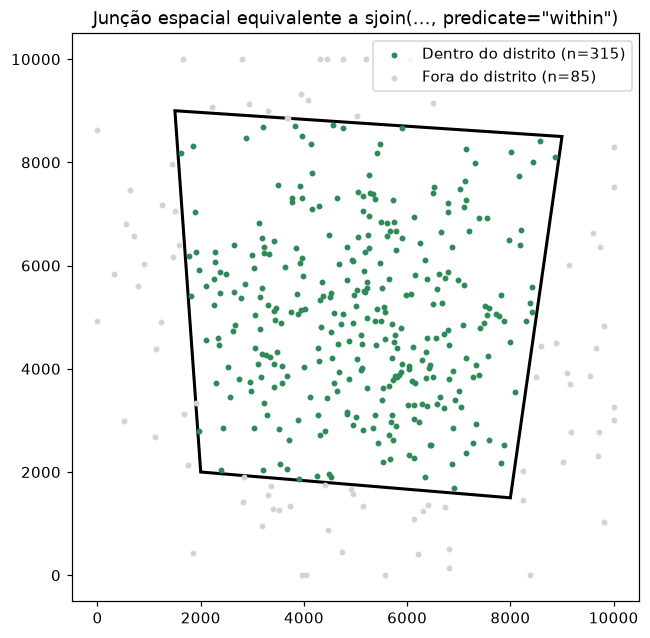

In [ ]:
# JUNÇÃO ESPACIAL (equivalente a gpd.sjoin ... predicate="within")
inside = distrito_path.contains_points(np.column_stack([dom_x, dom_y]))
fig, ax = plt.subplots(figsize=(6,6))
poly_patch = MplPolygon(distrito_coords, closed=True, facecolor="none", edgecolor="black", lw=2)
ax.add_patch(poly_patch)
ax.scatter(dom_x[inside], dom_y[inside], s=8, c="seagreen", label=f"Dentro do distrito (n={inside.sum()})")
ax.scatter(dom_x[~inside], dom_y[~inside], s=8, c="lightgray", label=f"Fora do distrito (n={(~inside).sum()})")
ax.set_title('Junção espacial equivalente a sjoin(..., predicate="within")')
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); # plt.savefig("/home/claude/out/2_sjoin.png"); plt.close()
print(f"Domicílios dentro do distrito: {inside.sum()} de {n_dom} ({inside.mean()*100:.1f}%)")

Q3

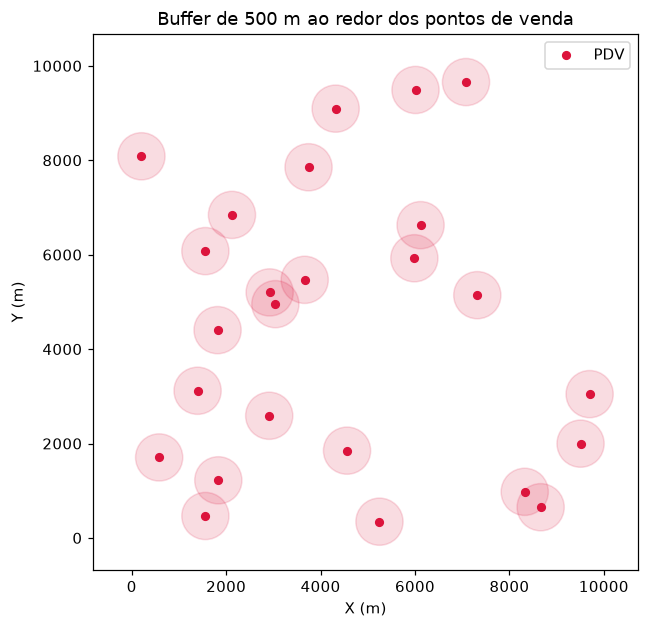

In [7]:
# BUFFER (500 m ilustrado em escala) em torno dos PDVs
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(pdv_x, pdv_y, c="crimson", s=25, zorder=3, label="PDV")
for x, y in zip(pdv_x, pdv_y):
    ax.add_patch(Circle((x,y), 500, facecolor="crimson", alpha=0.15, edgecolor="crimson"))
ax.set_title("Buffer de 500 m ao redor dos pontos de venda")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); #plt.savefig("/home/claude/out/1_buffer.png"); plt.close()

Q4

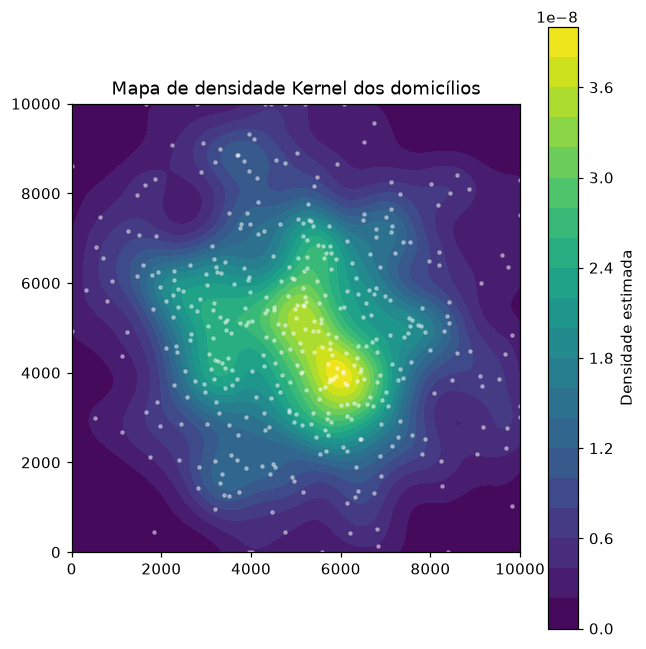

In [9]:
# KERNEL DENSITY
xy = np.vstack([dom_x, dom_y])
kde = gaussian_kde(xy, bw_method=0.25)
xx, yy = np.meshgrid(np.linspace(0,10000,150), np.linspace(0,10000,150))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
fig, ax = plt.subplots(figsize=(6,6))
c = ax.contourf(xx, yy, zz, levels=20, cmap="viridis")
ax.scatter(dom_x, dom_y, s=4, c="white", alpha=0.4)
plt.colorbar(c, ax=ax, label="Densidade estimada")
ax.set_title("Mapa de densidade Kernel dos domicílios")
ax.set_aspect("equal")
plt.tight_layout(); #plt.savefig("/home/claude/out/4_kde.png"); plt.close()

Q5

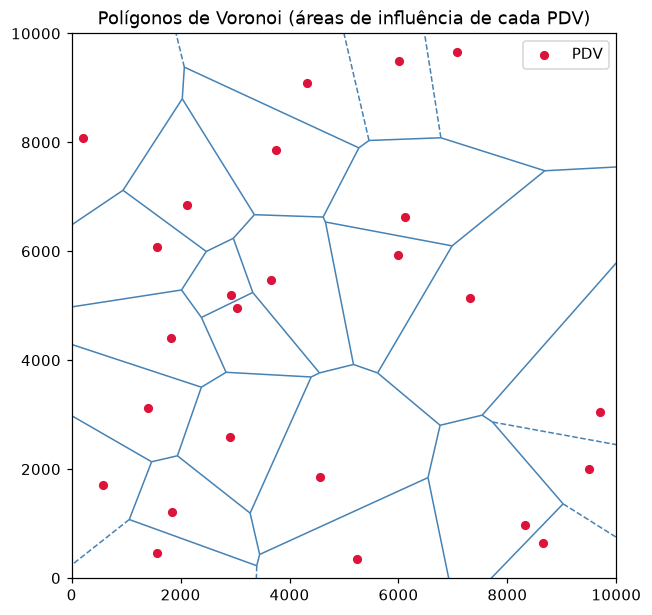

In [11]:
# VORONOI a partir dos PDVs (áreas de influência)
vor = Voronoi(np.column_stack([pdv_x, pdv_y]))
fig, ax = plt.subplots(figsize=(6,6))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="steelblue", point_size=0)
ax.scatter(pdv_x, pdv_y, c="crimson", s=25, zorder=3, label="PDV")
ax.set_xlim(0,10000); ax.set_ylim(0,10000)
ax.set_title("Polígonos de Voronoi (áreas de influência de cada PDV)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout()
# plt.savefig("/home/claude/out/5_voronoi.png")
# plt.close()

Q6

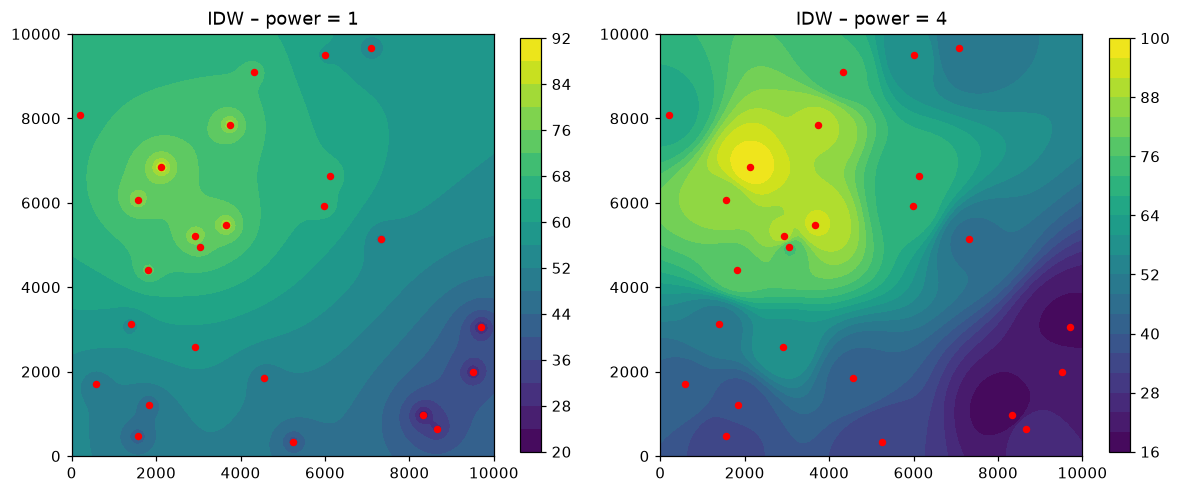

In [12]:
# IDW com dois valores de "power"
def idw(x, y, z, xi, yi, power):
    d = np.hypot(xi[...,None]-x, yi[...,None]-y)
    d = np.where(d==0, 1e-6, d)
    w = 1.0/d**power
    return (w*z).sum(axis=-1)/w.sum(axis=-1)

gx, gy = np.meshgrid(np.linspace(0,10000,120), np.linspace(0,10000,120))
z_p1 = idw(pdv_x, pdv_y, valor, gx, gy, power=1)
z_p4 = idw(pdv_x, pdv_y, valor, gx, gy, power=4)

fig, axes = plt.subplots(1,2, figsize=(11,5))
for ax, z, p in zip(axes, [z_p1, z_p4], [1,4]):
    c = ax.contourf(gx, gy, z, levels=20, cmap="viridis")
    ax.scatter(pdv_x, pdv_y, c="red", s=15)
    ax.set_title(f"IDW – power = {p}")
    ax.set_aspect("equal")
    plt.colorbar(c, ax=ax, shrink=0.8)
plt.tight_layout()
# plt.savefig("/home/claude/out/6_idw.png")
# plt.close()

Q7

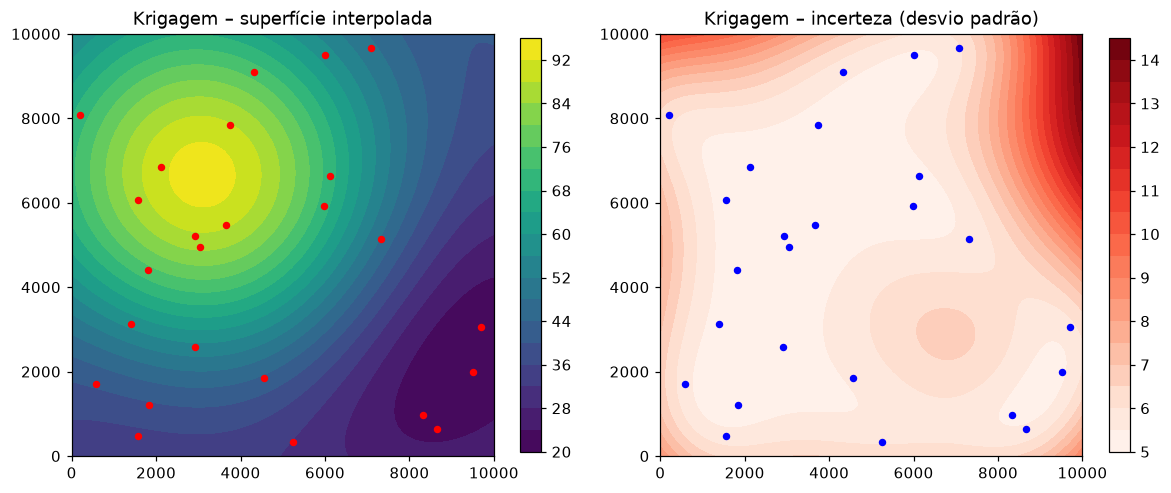

In [15]:
# KRIGAGEM (ilustrada via processo gaussiano - análogo à krigagem
#    ordinária; pacote pykrige não está disponível neste ambiente)
Xtrain = np.column_stack([pdv_x, pdv_y])
kernel = RBF(length_scale=2500, length_scale_bounds=(500,8000)) + WhiteKernel(noise_level=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gpr.fit(Xtrain, valor)
grid_pts = np.column_stack([gx.ravel(), gy.ravel()])
z_krig, sigma = gpr.predict(grid_pts, return_std=True)
z_krig = z_krig.reshape(gx.shape); sigma = sigma.reshape(gx.shape)

fig, axes = plt.subplots(1,2, figsize=(11,5))
c0 = axes[0].contourf(gx, gy, z_krig, levels=20, cmap="viridis")
axes[0].scatter(pdv_x, pdv_y, c="red", s=15)
axes[0].set_title("Krigagem – superfície interpolada")
plt.colorbar(c0, ax=axes[0], shrink=0.8)
c1 = axes[1].contourf(gx, gy, sigma, levels=20, cmap="Reds")
axes[1].scatter(pdv_x, pdv_y, c="blue", s=15)
axes[1].set_title("Krigagem – incerteza (desvio padrão)")
plt.colorbar(c1, ax=axes[1], shrink=0.8)
for ax in axes: ax.set_aspect("equal")
plt.tight_layout(); #plt.savefig("/home/claude/out/7_krigagem.png"); plt.close()

Q8

In [16]:
# MORAN GLOBAL implementado manualmente
#      (k-vizinhos mais próximos como matriz de pesos espaciais)
k = 5
tree = cKDTree(Xtrain)
_, idx = tree.query(Xtrain, k=k+1)  # inclui o próprio ponto
W = np.zeros((n_pdv, n_pdv))
for i in range(n_pdv):
    for j in idx[i][1:]:
        W[i, j] = 1.0
# padroniza por linha (row-standardization), padrão usual
W = W / W.sum(axis=1, keepdims=True)

z = (valor - valor.mean())/valor.std()
n = n_pdv
S0 = W.sum()
num = 0.0
for i in range(n):
    for j in range(n):
        num += W[i,j]*z[i]*z[j]
I_global = (n/S0) * (num/np.sum(z**2))

# teste de significância por permutação
n_perm = 999
I_perm = np.zeros(n_perm)
for p in range(n_perm):
    zp = np.random.permutation(z)
    I_perm[p] = (n/S0) * np.sum(W*np.outer(zp,zp)) / np.sum(zp**2)
p_value = (np.sum(np.abs(I_perm) >= np.abs(I_global)) + 1) / (n_perm + 1)

print(f"\nÍndice de Moran Global (I): {I_global:.4f}")
print(f"E[I] esperado sob aleatoriedade: {-1/(n-1):.4f}")
print(f"p-valor (permutação, {n_perm} simulações): {p_value:.4f}")



Índice de Moran Global (I): 0.8013
E[I] esperado sob aleatoriedade: -0.0417
p-valor (permutação, 999 simulações): 0.0010


Q9


Distribuição LISA:
Counter({'HH': 13, 'LL': 10, 'LH': 2})

Todas as figuras foram salvas em /home/claude/out/


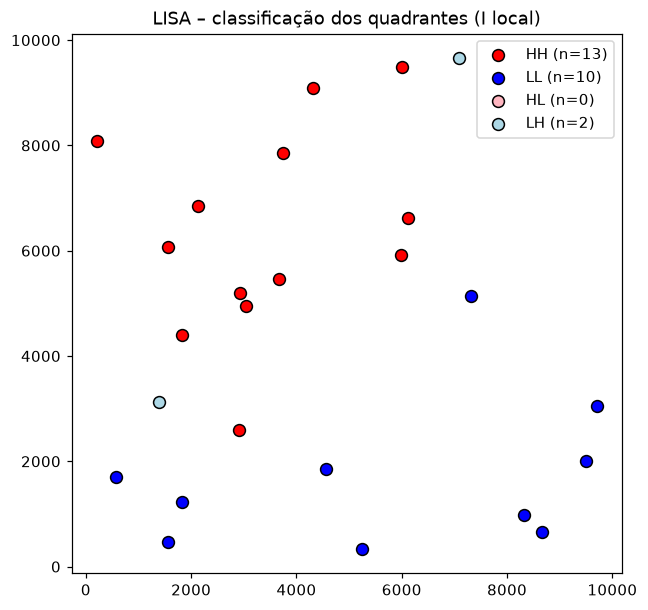

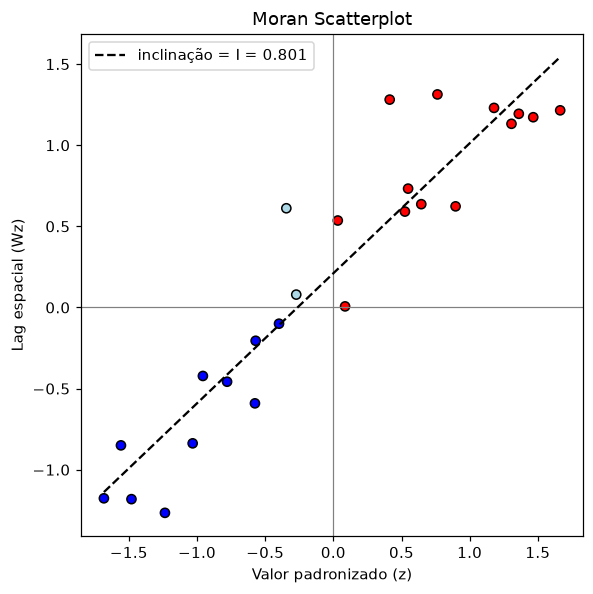

In [19]:
# LOCAL (LISA) implementado manualmente
#      (k-vizinhos mais próximos como matriz de pesos espaciais)
Ii = z * (W @ z)
# classificação de quadrantes
lag_z = W @ z
quad = np.empty(n, dtype=object)
for i in range(n):
    if z[i] >= 0 and lag_z[i] >= 0: quad[i] = "HH"
    elif z[i] < 0 and lag_z[i] < 0: quad[i] = "LL"
    elif z[i] >= 0 and lag_z[i] < 0: quad[i] = "HL"
    else: quad[i] = "LH"

colors = {"HH":"red", "LL":"blue", "HL":"lightpink", "LH":"lightblue"}
fig, ax = plt.subplots(figsize=(6,6))
for cat, col in colors.items():
    m = quad==cat
    ax.scatter(pdv_x[m], pdv_y[m], c=col, s=60, edgecolor="k", label=f"{cat} (n={m.sum()})")
ax.set_title("LISA – classificação dos quadrantes (I local)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); #plt.savefig("/home/claude/out/8_9_lisa.png"); plt.close()

# Moran scatterplot
fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.scatter(z, lag_z, c=[colors[q] for q in quad], edgecolor="k")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
b, a = np.polyfit(z, lag_z, 1)
xs = np.linspace(z.min(), z.max(), 10)
ax.plot(xs, a+b*xs, "k--", label=f"inclinação = I = {I_global:.3f}")
ax.set_xlabel("Valor padronizado (z)"); ax.set_ylabel("Lag espacial (Wz)")
ax.set_title("Moran Scatterplot")
ax.legend()
plt.tight_layout(); #plt.savefig("/home/claude/out/moran_scatter.png"); plt.close()

print("\nDistribuição LISA:")
import collections
print(collections.Counter(quad))
print("\nTodas as figuras foram salvas em /home/claude/out/")